<a href="https://colab.research.google.com/github/dimelnychuk91-lgtm/Data_Analytics_Portfolio/blob/main/Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/Mate/Mate_homework_Colab

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate/Mate_homework_Colab


# Завантаження та перевірка датасету

In [10]:
# Завантажуємо та перевіряємо датасет
events = pd.read_csv('events.csv')
products = pd.read_csv('products.csv')
countries = pd.read_csv('countries.csv')

print('--- Events Info ---')
events.info()
print('\n--- Products Info ---')
products.info()
print('\n--- Countries Info ---')
countries.info()

display(events.head())
display(products.head())
display(countries.head())

--- Events Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB

--- Products Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


## Data overview, висновки:
Датасет містить дані про торгові операції компанії та складається з трьох взаємопов'язаних таблиць.

### Таблиця events.csv
**Це основна таблиця з фактами продажів.**

Order ID — унікальний ідентифікатор замовлення.

Order Date — дата оформлення замовлення клієнтом.

Ship Date — дата фактичного відвантаження товару.

Order Priority — пріоритетність виконання.

Country Code — код країни, куди здійснюється продаж.

Product ID — код товару.

Sales Channel — канал продажу.

Units Sold — кількість проданих одиниць товару.

Unit Price — ціна реалізації за одну одиницю.

Unit Cost — собівартість однієї одиниці товару.

### Таблиця products.csv
**Довідник товарів**

id — унікальний код товару.

item_type — назва категорії або типу товару.

### Таблиця countries.csv
**Географічний довідник**
name — повна назва країни.

alpha-2 — дволітерний міжнародний код країни.

alpha-3 — трилітерний міжнародний код країни.

region — глобальний регіон (континент).

sub-region — уточнений географічний регіон.

### Ключові поля для об'єднання:
Спільне поле для товарів: events.Product ID -> products.id.

Спільне поле для географії: events.Country Code -> countries.alpha-3


# Очистка та підготовка даних

In [11]:
# Починаємо чистку з перетворення дат
events['Order Date'] = pd.to_datetime(events['Order Date'])
events['Ship Date'] = pd.to_datetime(events['Ship Date'])

# Перевіряємо пропуски
display(events[events['Units Sold'].isna()])
missing_pct = events['Country Code'].isna().mean() * 100
print(f"Пропущено Country Code: {missing_pct:.2f}%")

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
183,217165648,2014-05-20,2014-06-08,M,ESP,8875,Offline,NaN,421.89,364.69
319,309655511,2014-05-05,2014-05-21,C,HRV,3127,Offline,NaN,81.73,56.67


Пропущено Country Code: 6.17%


In [12]:
# Видаляємо рядки з пустими Units Sold
events = events.dropna(subset=['Units Sold'])

# Заповнюємо пусті Country Code значенням 'Unknown'
events['Country Code'] = events['Country Code'].fillna('Unknown')

# Перевірка на дублікати
print(f'Кількість повних дублікатів: {events.duplicated().sum()}')

# Дослідження текстових аномалій
events['Country Code'] = events['Country Code'].str.strip().str.upper()

# Дослідження аномалій в цифрах
events[['Unit Price', 'Unit Cost', 'Units Sold']].describe()

# Перевірка Units Sold на цілісність
fractional_units = events[events['Units Sold'] % 1 != 0]
print(f'Рядків з дробовими продажами: {len(fractional_units)}')



# Результат очищення
events.info()

Кількість повних дублікатів: 0
Рядків з дробовими продажами: 0
<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 114.1+ KB


## Data cleaning, висновки:

### **Пропуски:**

Виявив 82 пропуски в Country Code (6.1% від усіх даних). Щоб не втратити інформацію про обсяги продажів та прибуток, міняю пропуски на 'Unknown'. Рядки з пустими Units Sold (2 шт.) були видалені, оскільки їх кількість мізерна і вони не дозволяють коректно розрахувати фінансові метрики.

### **Типи даних:**

Колонки з датами конвертовано у формат `datetime` для розрахунку тривалості доставки та аналізу сезонності.

### **Аномалії та дублікати:**

Повних дублікатів не виявлено. Числові дані знаходяться в межах норми (відсутні від'ємні або нульові значення).

In [13]:
# Об'єднання (Merging) та основні метрики

# Додаємо назви товарів
df = events.merge(products, left_on='Product ID', right_on='id', how='left')

# Додаємо географію
df = df.merge(countries, left_on='Country Code', right_on='alpha-3', how='left')

# Очищуємо зайве, виправляємо та перейменовуємо
df = df.drop(columns=['id', 'alpha-3', 'alpha-2'])
df = df.rename(columns={'item_type': 'Product Category', 'name': 'Country'})
df['Sales Channel'] = df['Sales Channel'].str.capitalize()

# Розраховуємо ключові фінансові метрики
df['Total Revenue'] = df['Units Sold'] * df['Unit Price']
df['Total Cost'] = df['Units Sold'] * df['Unit Cost']
df['Total Profit'] = df['Total Revenue'] - df['Total Cost']

print(f'Загальна кількість замовлень: {df['Order ID'].nunique()}')
print(f'Загальний прибуток: {df['Total Profit'].sum():,.2f}')
print(f'Кількість охоплених країн: {df['Country'].nunique()}')
print(f'Найпопулярніша категорія (за кількістю): {df['Product Category'].value_counts().idxmax()}')


Загальна кількість замовлень: 1328
Загальний прибуток: 501,434,459.00
Кількість охоплених країн: 45
Найпопулярніша категорія (за кількістю): Office Supplies


In [14]:
# Додаткові метрики
# Розрахунок часу доставки (в днях)
df['delivery_time'] = (df['Ship Date'] - df['Order Date']).dt.days
df['order_year'] = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.month
df['day_of_week'] = df['Order Date'].dt.day_name()

# Рахуємо додаткові метрики, щоб вичислити рентабельність та середній час доставки
total_revenue = df['Total Revenue'].sum()
total_profit = df['Total Profit'].sum()
avg_order_value = total_revenue / df['Order ID'].nunique()
profit_margin = (total_profit / total_revenue) * 100
avg_delivery = df['delivery_time'].mean()

print(f'Середній чек (AOV): ${avg_order_value:,.2f}')
print(f"Загальна рентабельність (Margin): {profit_margin:.2f}%")
print(f"Середній час доставки: {avg_delivery:.1f} дн.")

# Подивимось на розподіл по каналах продажу
display(df.groupby('Sales Channel')['Total Profit'].sum().round(2))

Середній чек (AOV): $1,281,723.95
Загальна рентабельність (Margin): 29.46%
Середній час доставки: 24.8 дн.


,Total Profit
Sales Channel,
Offline,2.534665e+08
Online,2.479679e+08


In [15]:
# Візуалізація: категорії, географія та канали

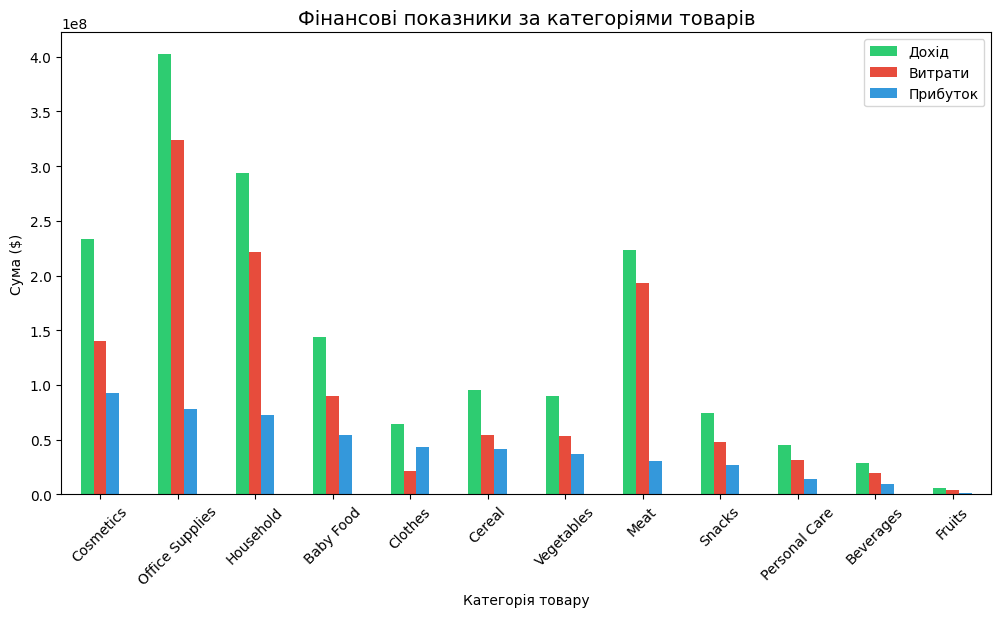

In [16]:
# Аналіз за категоріями
# Группуємо дані та будуємо графік
category_finance = df.groupby('Product Category')[['Total Revenue', 'Total Cost', 'Total Profit']].sum().sort_values(by='Total Profit', ascending=False)
category_finance.plot(kind='bar', figsize=(12, 6), color=['#2ecc71', '#e74c3c', '#3498db'])

plt.title(f'Фінансові показники за категоріями товарів', fontsize=14)
plt.xlabel('Категорія товару')
plt.ylabel('Сума ($)')
plt.xticks(rotation=45)
plt.legend(["Дохід", "Витрати", "Прибуток"])

plt.show()

/tmp/ipykernel_2091/126552512.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popularity.values, y=popularity.index, palette='viridis')


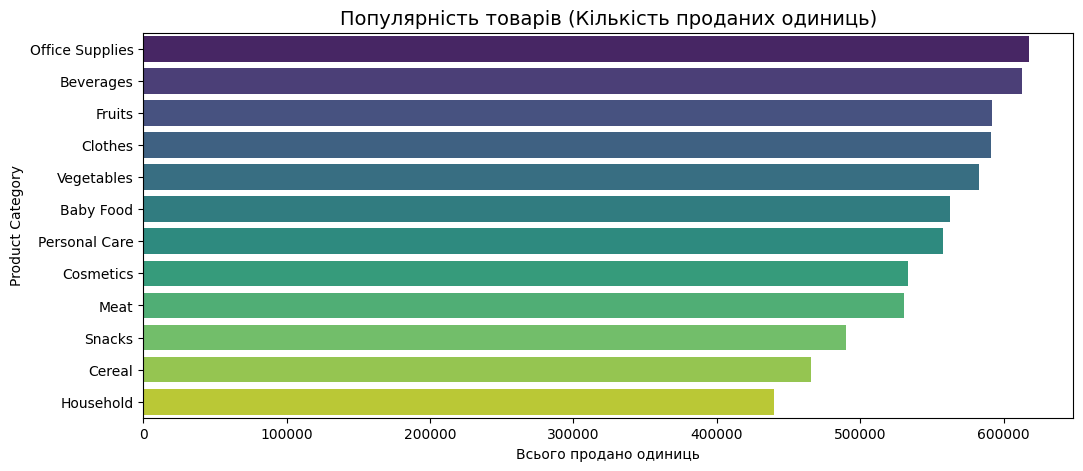

In [17]:
# Аналіз популярності
# Рахуємо загальну кількість проданих одиниць для кожної категорії
popularity = df.groupby('Product Category')['Units Sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=popularity.values, y=popularity.index, palette='viridis')

plt.title('Популярність товарів (Кількість проданих одиниць)', fontsize=14)
plt.xlabel('Всього продано одиниць')
plt.show()

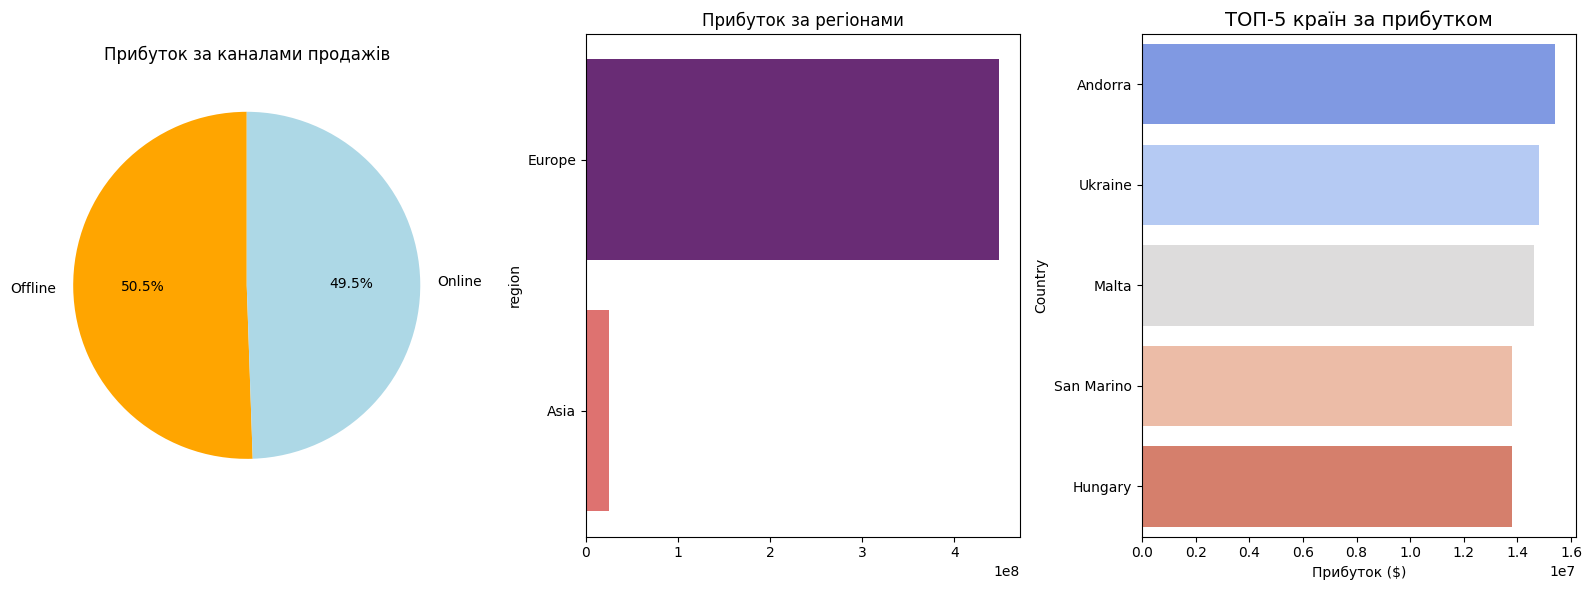

In [18]:
# Географія та канали продажів
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
top_countries = df.groupby('Country')['Total Profit'].sum().sort_values(ascending=False).head(5)

# Графік 1: Канали продажів
channel_data = df.groupby('Sales Channel')['Total Profit'].sum()
ax[0].pie(channel_data, labels=channel_data.index, autopct='%1.1f%%', startangle=90, colors=['orange', 'lightblue'])
ax[0].set_title('Прибуток за каналами продажів')

# Графік 2: Регіони за прибутком
region_data = df.groupby('region')['Total Profit'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=region_data.values, y=region_data.index, ax=ax[1], hue=region_data.index, palette='magma', legend=False)
ax[1].set_title('Прибуток за регіонами')

# Графік 3: ТОП-5 країн за прибутком
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax[2], hue=top_countries.index, palette='coolwarm')
ax[2].set_title('ТОП-5 країн за прибутком', fontsize=14)
ax[2].set_xlabel('Прибуток ($)')

plt.tight_layout()
plt.show()

# Аналіз часу між замовленням та його відвантаженням

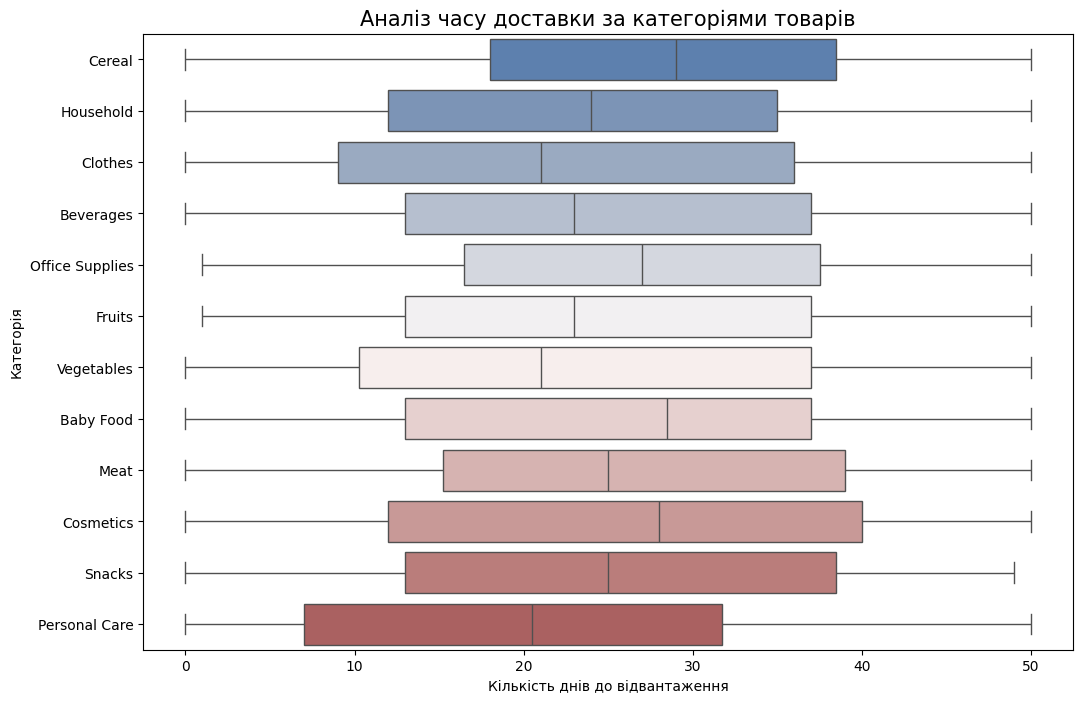

In [19]:
# Аналіз часу між замовленням та його відвантаженням в розрізі категорій
# Рахуємо дні доставки
df['delivery_time'] = (df['Ship Date'] - df['Order Date']).dt.days

# Будуємо графік
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='delivery_time', y='Product Category', hue='Product Category', palette='vlag', legend=False)

plt.title('Аналіз часу доставки за категоріями товарів', fontsize=15)
plt.xlabel('Кількість днів до відвантаження')
plt.ylabel('Категорія')

plt.show()

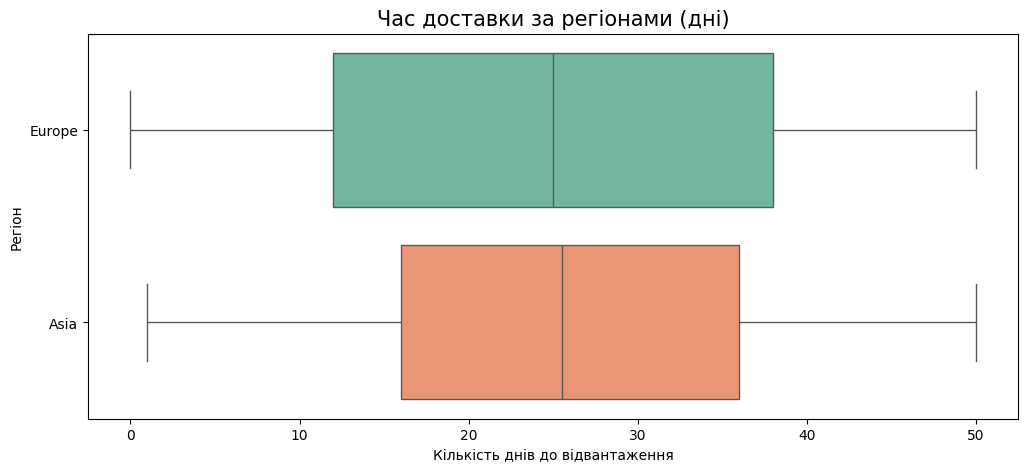

In [20]:
# Аналіз у розрізі регіонів

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='delivery_time', y='region', hue='region', palette='Set2', legend=False)

plt.title('Час доставки за регіонами (дні)', fontsize=15)
plt.xlabel('Кількість днів до відвантаження')
plt.ylabel('Регіон')

plt.show()

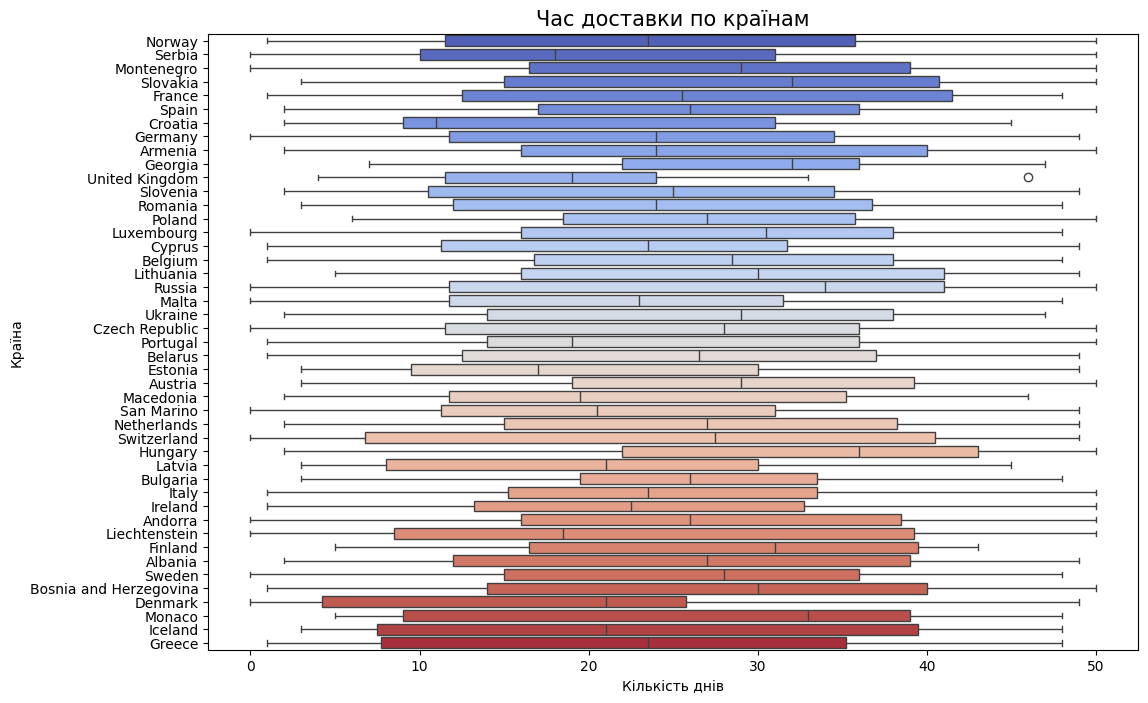

In [21]:
# Аналіз у розрізі країн

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df,
    x='delivery_time',
    y='Country',
    hue='Country',
    palette='coolwarm'
)

plt.title('Час доставки по країнам', fontsize=15)
plt.xlabel('Кількість днів')
plt.ylabel('Країна')
plt.legend([],[], frameon=False)
plt.show()

## Висновок щодо аналіза часу між замовленням та його відвантаженням
Попри візуальний розкид даних, медіанне значення часу відвантаження для всіх категорій товарів, регіонів та країн є майже ідентичним і становить 25 днів. Це свідчить про те, що логістична система компанії працює за єдиним стандартом для всього світу, або відсутність оптимізації за категоріями та країнами.

Передбачуваність процесів: 50% усіх замовлень відвантажуються в інтервалі від 12 до 37 днів. Це вказує на те, що компанія не має "пріоритетних" категорій товарів або "швидких" регіонів - логістичне навантаження розподілене рівномірно.

Відсутність географічної дискримінації: Аналіз за всіма країнами підтвердив, що віддаленість регіону не впливає на швидкість обробки замовлення. Як для Європи, так і для Азії, середня швидкість відвантаження залишається стабільною.

Потенціал для оптимізації: Наявність замовлень із терміном відвантаження 40-50 днів у кожній категорії є точкою росту. Оскільки ці затримки не залежать від типу товару чи країни, причиною можуть бути внутрішні складські процеси або черги на виробництві, які потребують окремого аудиту.

# Аналіз залежності прибутку від часу, необхідного на відвантаження товару

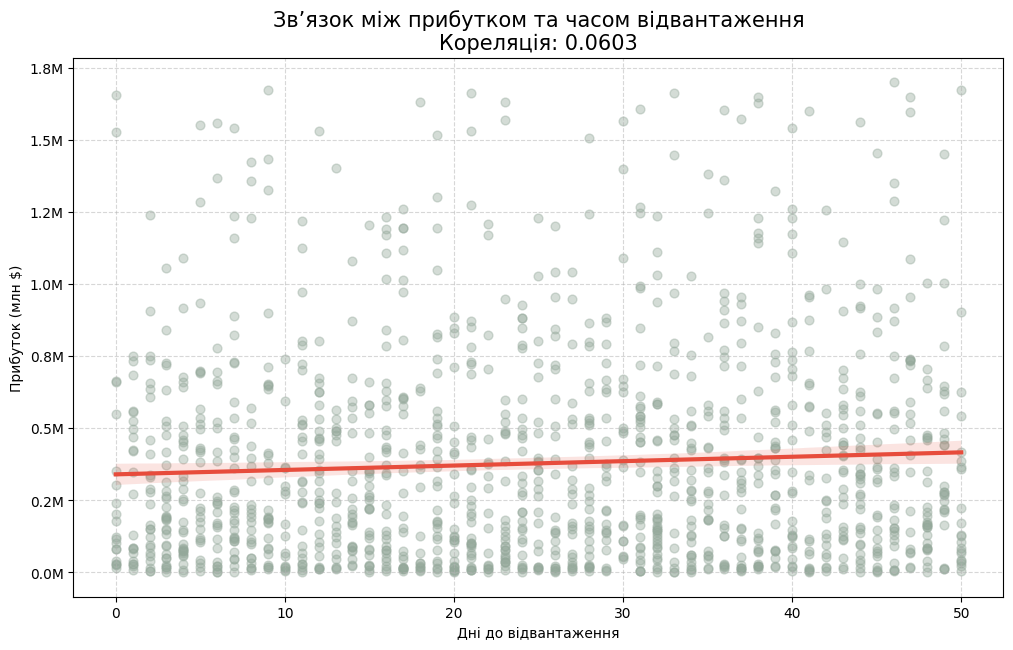

Коефіцієнт кореляції: 0.0603


In [22]:
# Налаштовуємо та будуємо графік
plt.figure(figsize=(12, 7))
sns.regplot(data=df, x='delivery_time', y='Total Profit', scatter_kws={'alpha':0.4, 'color':'#94a89a', 's':40}, line_kws={'color':'#e74c3c', 'linewidth':3})

# Форматуємо вісь Y у мільйони
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

# Розраховуємо кореляцію для заголовка
corr = df['delivery_time'].corr(df['Total Profit'])

plt.title(f'Зв’язок між прибутком та часом відвантаження\nКореляція: {corr:.4f}', fontsize=15)
plt.xlabel('Дні до відвантаження')
plt.ylabel('Прибуток (млн $)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Коефіцієнт кореляції: {corr:.4f}")

## Висновок щодо прибутку від часу, необхідного на відвантаження товару

Коефіцієнт кореляції становить приблизно 0.06. Це майже нульова або незначна кореляція. Це означає, що прибуток компанії ніяк не залежить від того, чи відвантажили товар у день замовлення, чи через 50 днів. Для бізнесу це тривожний сигнал. У здорових процесах зазвичай спостерігається залежність: або великі (прибуткові) замовлення готуються довше, або навпаки - швидкий сервіс стимулює продажі дорожчих товарів. Тут ми бачимо повний розрив між логістикою та фінансами.

# Аналіз динаміки продажів (у часі) у розрізі категорій товарів, країн, регіонів

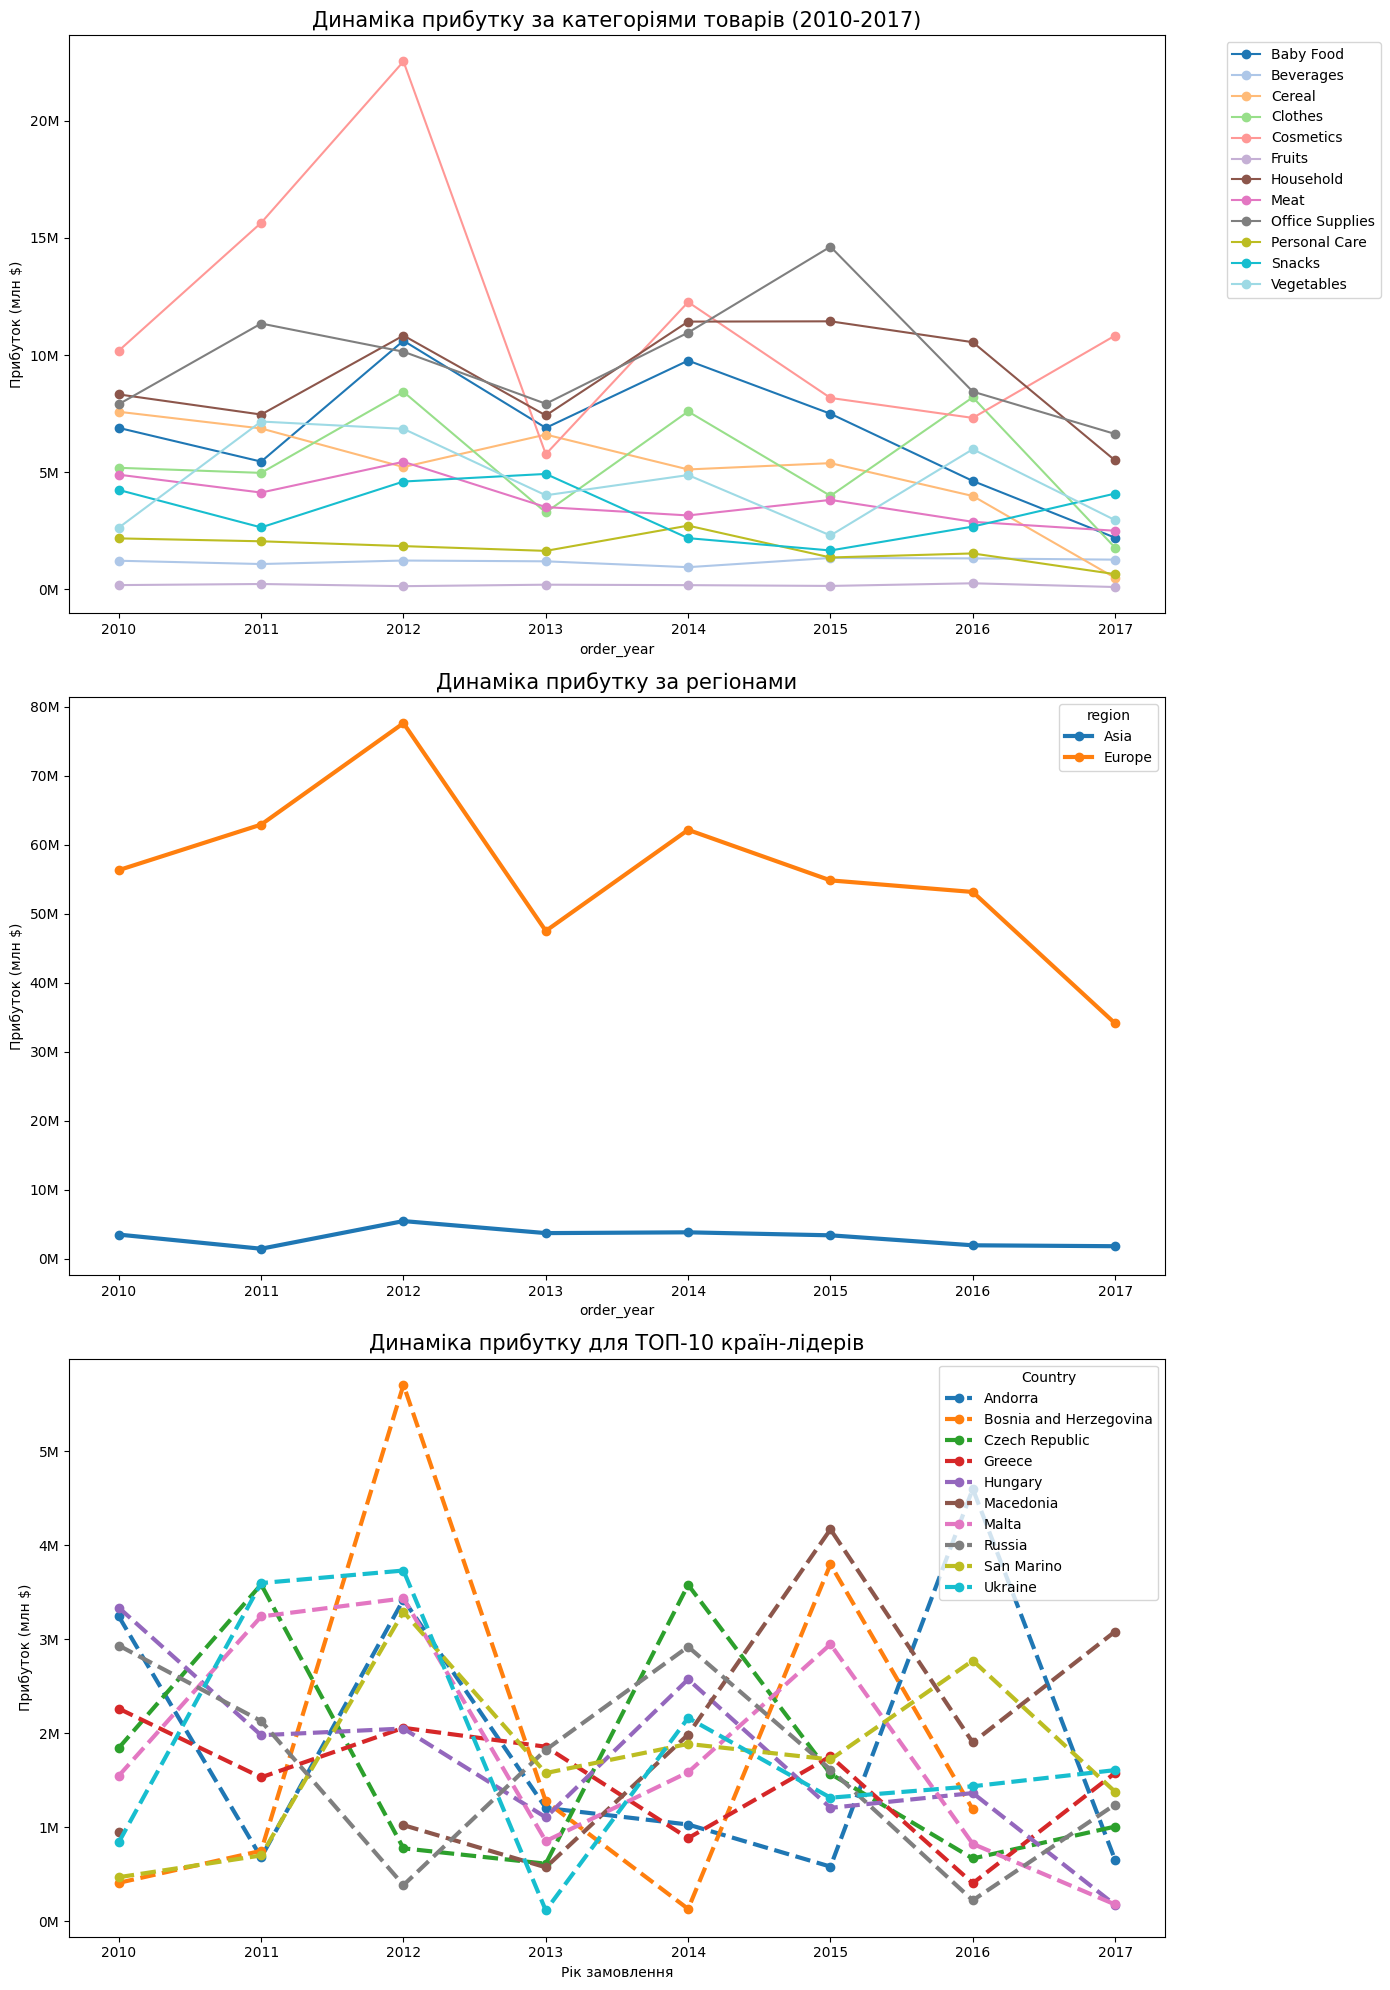

In [23]:
# Готуємо дані для динаміки
# Прибуток по роках та категоріях
pivot_category = df.groupby(['order_year', 'Product Category'])['Total Profit'].sum().unstack()

# Прибуток по роках та регіонах
pivot_region = df.groupby(['order_year', 'region'])['Total Profit'].sum().unstack()

# Для країн візьмемо ТОП-10 за весь час, щоб не перевантажувати графік
top_10_countries = df.groupby('Country')['Total Profit'].sum().nlargest(10).index
pivot_country = df[df['Country'].isin(top_10_countries)].groupby(['order_year', 'Country'])['Total Profit'].sum().unstack()

# Будуємо графіки
fig, ax = plt.subplots(3, 1, figsize=(14, 20))

# Динаміка за категоріями
pivot_category.plot(kind='line', marker='o', ax=ax[0], colormap='tab20')
ax[0].set_title('Динаміка прибутку за категоріями товарів (2010-2017)', fontsize = 15)
ax[0].set_ylabel('Прибуток (млн $)')
# Виносимо легенду за межі графіка
ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

# Динаміка за регіонами
pivot_region.plot(kind='line', marker='o', ax=ax[1], linewidth=3)
ax[1].set_title('Динаміка прибутку за регіонами', fontsize=15)
ax[1].set_ylabel('Прибуток (млн $)')
ax[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

# Динаміка ТОП-5 країн
pivot_country.plot(kind='line', marker='o', ax=ax[2], linewidth=3, linestyle='--')
ax[2].set_title('Динаміка прибутку для ТОП-10 країн-лідерів', fontsize=15)
ax[2].set_xlabel('Рік замовлення')
ax[2].set_ylabel('Прибуток (млн $)')
ax[2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()




## Висновки щодо аналізу динаміки продажів (у часі) у розрізі категорій товарів, країн, регіонів

У 2012 були аномальні прибутки. Прибуток підскочив на 24% вище середнього. Схоже на закриття кількох гігантських контрактів, бо в інші роки все набагато спокійніше.

Графік постійно стрибає то вгору, то вниз. Це нормально для оптового бізнесу: одна велика закупка робить план на місяць, а потім настає затишшя.

Стабільна база це товари для дому (Household) та офісу (Office Supplies).

Розподіл по країнам не показує чітко виражених лідерів. Немає ринку, який би стабільно ріс. Сьогодні лідер - Україна, завтра - Андорра. Бізнес тримається на разових великих угодах у різних куточках світу, а не на лояльній базі клієнтів.

# Аналіз продажів товарів за місяцями та днями тижня

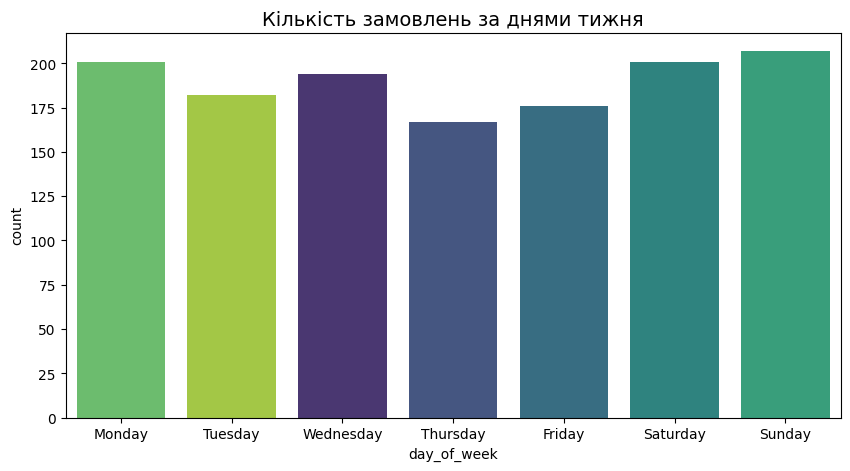

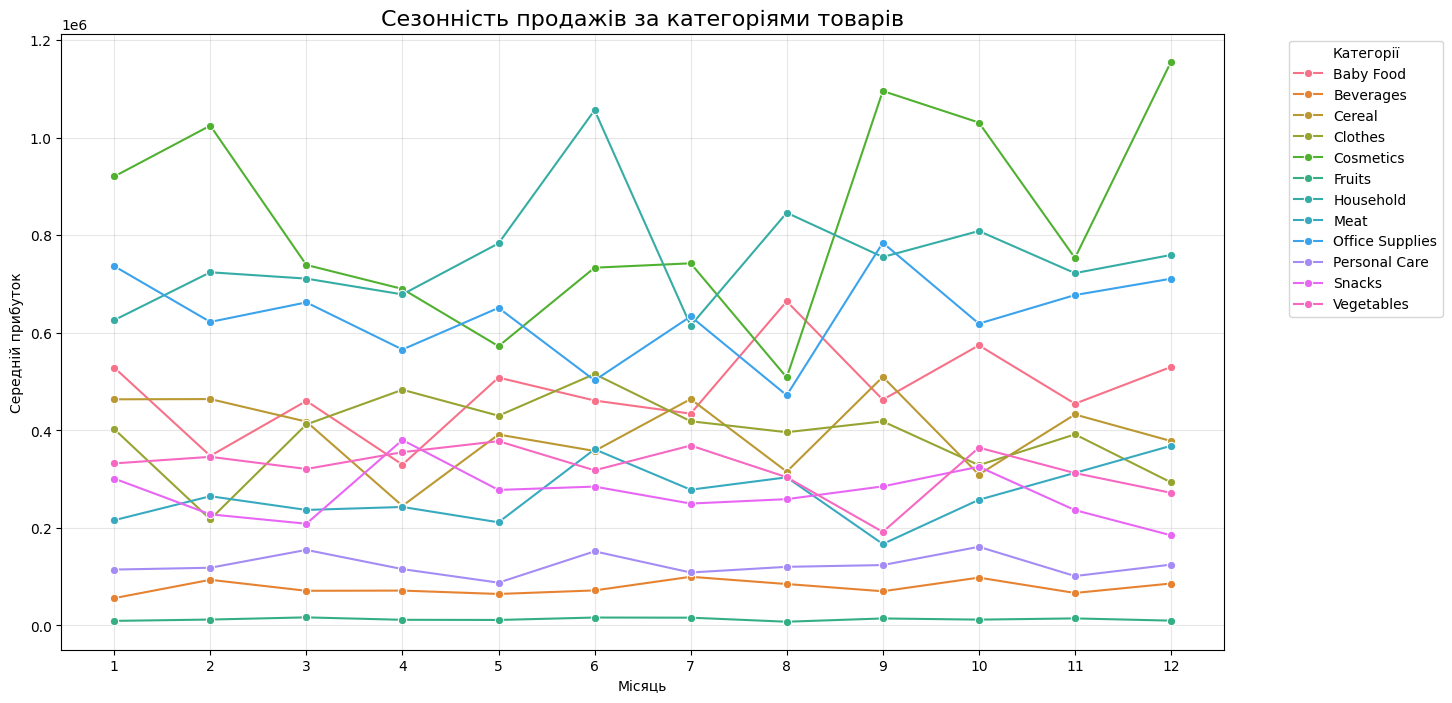

In [24]:
# Створюємо правильний порядок днів
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Будуємо графік
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='day_of_week', order=days_order, palette='viridis', hue='day_of_week', legend=False)
plt.title('Кількість замовлень за днями тижня', fontsize=14)
plt.show()

# Аналіз сезонності (по місяцях) за категоріями товарів
category_seasonality = df.groupby(['order_month', 'Product Category'])['Total Profit'].mean().unstack()

plt.figure(figsize=(15, 8))
sns.lineplot(data=category_seasonality, dashes=False, marker='o')

plt.title('Сезонність продажів за категоріями товарів', fontsize=16)
plt.xlabel('Місяць')
plt.ylabel('Середній прибуток')
plt.xticks(range(1, 13))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Категорії')
plt.grid(True, alpha=0.3)
plt.show()


## Висновки щодо аналізу продажів товарів за місяцями та днями тижня


У червні пік продажів. Більшість категорій (Напої, Косметика, Офісні товари) "вистрілюють" саме в червні. Це не схоже на звичайний попит клієнтів (як-от купівля пуховиків взимку). Скоріше за все, це бізнес-сезонність: закриття піврічних контрактів або великі планові закупівлі оптовиків.

**Специфічні піки категорій:**

*М'ясо:* Пік у листопаді. Це схоже на підготовку до святкового сезону.

*Особиста гігієна та дитяче харчування:* Пік у липні. Можливо, пов'язано з літнім періодом.

*Офісні товари:* Мають пік у лютому. Це часто час оновлення запасів у компаніях після початку нового фінансового року.

**Висновок:** Товари можна назвати сезонними, але це "графік закупівель", а не погода. Попит диктується не температурою за вікном, а внутрішніми циклами компаній-покупців.

# Поглиблений аналіз та бізнес-гіпотези

## ABC-аналіз (Принцип Парето)

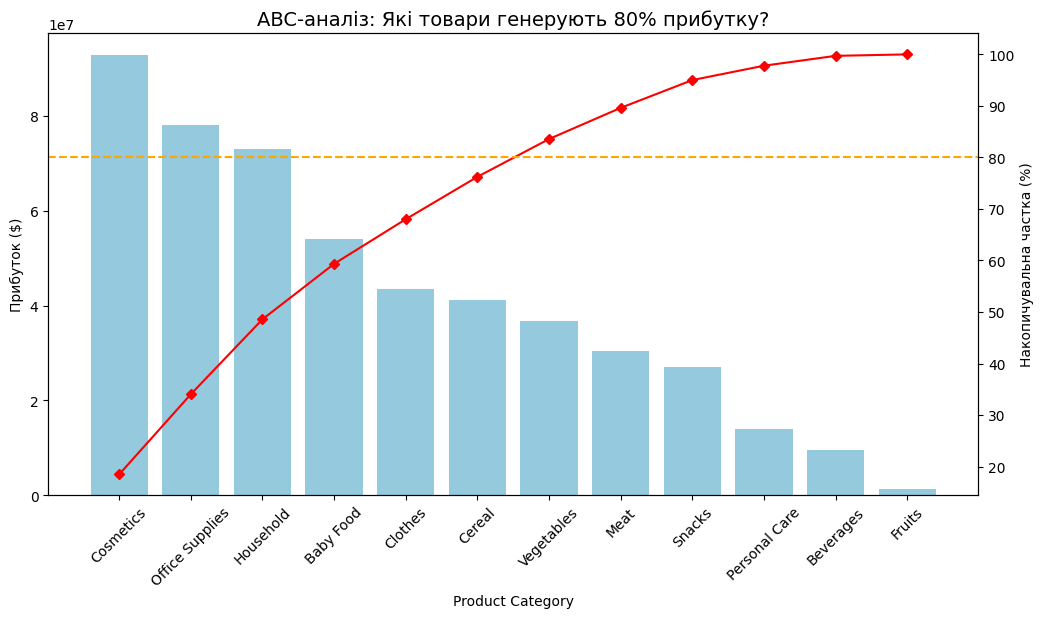

In [32]:
# Рахуємо накопичувальний прибуток по категоріях
abc = df.groupby('Product Category')['Total Profit'].sum().sort_values(ascending=False).reset_index()
abc['Cumulative_Pct'] = 100 * abc['Total Profit'].cumsum() / abc['Total Profit'].sum()

# Візуалізація
fig, ax1 = plt.subplots(figsize=(12, 6))

# Стовпчики прибутку
sns.barplot(data=abc, x='Product Category', y='Total Profit', ax=ax1, color='skyblue')

# Виправлений рядок для повороту тексту без попереджень
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel('Прибуток ($)')

# Лінія Парето (80%)
ax2 = ax1.twinx()
ax2.plot(abc['Product Category'], abc['Cumulative_Pct'], color='red', marker='D', ms=5)
ax2.axhline(80, color='orange', linestyle='--', label='Межа 80%')
ax2.set_ylabel('Накопичувальна частка (%)')

plt.title('ABC-аналіз: Які товари генерують 80% прибутку?', fontsize=14)
plt.show()

### Висновки щодо ABC-аналізу

На графіку видно, що категорії зліва від перетину з помаранчевою лінією (Cosmetics, Office Supplies, Household тощо) формують 80% усього прибутку. Саме на їх наявності на складі бізнесу варто фокусуватися найбільше

# Теплова карта сезонності

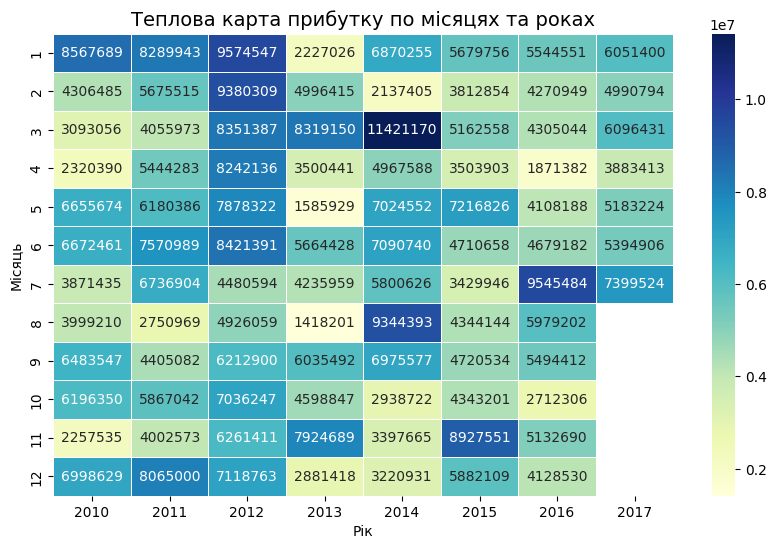

In [30]:
# Створюємо зведену таблицю для теплової карти
pivot_table = df.pivot_table(index='order_month', columns='order_year', values='Total Profit', aggfunc='sum')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='YlGnBu', linewidths=.5)

plt.title('Теплова карта прибутку по місяцях та роках', fontsize=14)
plt.ylabel('Місяць')
plt.xlabel('Рік')
plt.show()

## Висновки по тепловій карті

Теплова карта дозволяє швидко ідентифікувати найбільш прибуткові місяці. Це корисно для планування рекламних кампаній — ми бачимо, в які періоди попит історично найвищий

# Розкид прибутку: Online vs Offline

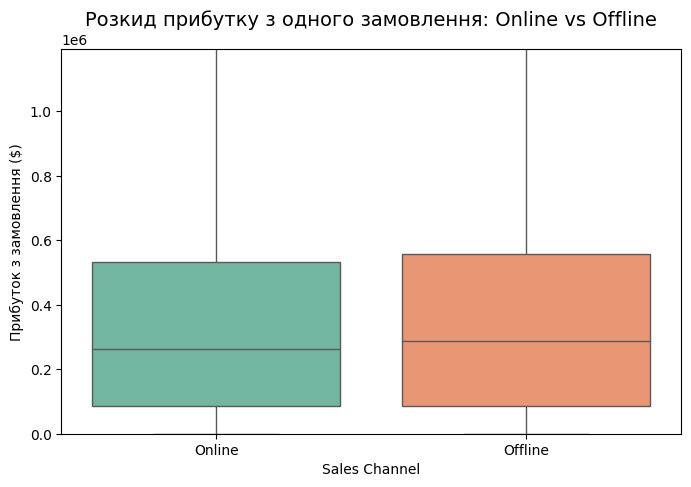

In [34]:
plt.figure(figsize=(8, 5))

# Додали hue='Sales Channel' та legend=False, як того вимагає нова версія Seaborn
sns.boxplot(data=df, x='Sales Channel', y='Total Profit', hue='Sales Channel', palette='Set2', legend=False)

plt.title('Розкид прибутку з одного замовлення: Online vs Offline', fontsize=14)
# Обрізаємо аномально великі замовлення (викиди), щоб графік був читабельним
plt.ylim(0, df['Total Profit'].quantile(0.95))
plt.ylabel('Прибуток з замовлення ($)')
plt.show()

## Висновок щодо розподілу Online vs Offline

Аналіз розподілу показує відсутність суттєвої різниці між онлайн та офлайн каналами продажу. Медіанний прибуток з одного замовлення та загальний розкид сум практично ідентичні.